#### ДЗ_4 Деревья решений

#### Задание: 
* В коде из методички реализуйте один или несколько из критериев останова (количество листьев, количество используемых признаков, глубина дерева и т.д.).
* Для задачи классификации обучить дерево решений с использованием критериев разбиения Джини и Энтропия. Сравнить качество классификации, сделать выводы.
* *Построить визуализацию дерева для реализации модели через библиотеку DecisionTreeClassifier

In [62]:
import matplotlib.pyplot as plt
import random
from matplotlib.colors import ListedColormap
from sklearn import datasets
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [63]:
# сгенерируем данные
classification_data, classification_labels = datasets.make_classification(n_features = 2, n_informative = 2, 
                                                      n_classes = 2, n_redundant=0, 
                                                      n_clusters_per_class=1, random_state=5)

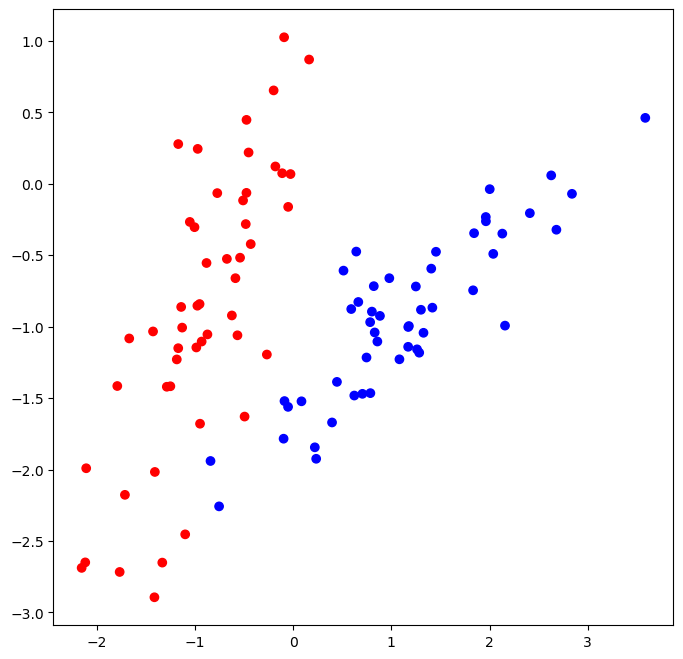

In [64]:
# визуализируем сгенерированные данные

colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(8,8))
plt.scatter(list(map(lambda x: x[0], classification_data)), list(map(lambda x: x[1], classification_data)), 
              c=classification_labels, cmap=colors)

In [65]:
# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    classification_data, classification_labels, test_size=0.3, random_state=42
)

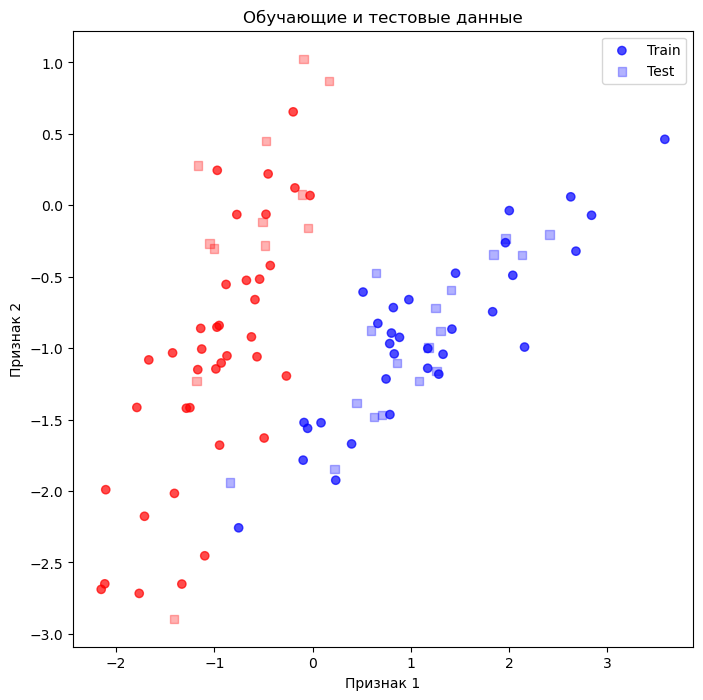

In [66]:
# Визуализируем сгенерированные данные
colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(8, 8))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, alpha=0.7, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colors, alpha=0.3, marker='s', label='Test')
plt.title("Обучающие и тестовые данные")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.show()

In [67]:
# Функция для визуализации решающих границ
def get_meshgrid(data, step=.05, border=.5):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

In [68]:
def visualize_tree(clf, X_train, y_train, X_test, y_test, title="Decision Tree"):
    # Создаем сетку для визуализации
    xx, yy = get_meshgrid(classification_data, step=0.05, border=0.5)
    
    # Предсказания для каждой точки сетки
    mesh_predictions = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    mesh_predictions = mesh_predictions.reshape(xx.shape)
    
    # Создаем график
    plt.figure(figsize=(10, 8))
    
    # Отображаем решающие границы
    plt.contourf(xx, yy, mesh_predictions, cmap=light_colors, alpha=0.4)
    
    # Отображаем точки данных
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, alpha=0.8, label='Train')
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colors, alpha=0.3, marker='s', label='Test')
    
    plt.title(f"{title}\nAccuracy: {accuracy_score(y_test, clf.predict(X_test)):.3f}")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.legend()
    plt.show()

=== 1. Базовое дерево (без ограничений) ===
Глубина дерева: 3
Количество листьев: 6
Accuracy на обучающей выборке: 1.000
Accuracy на тестовой выборке: 0.867


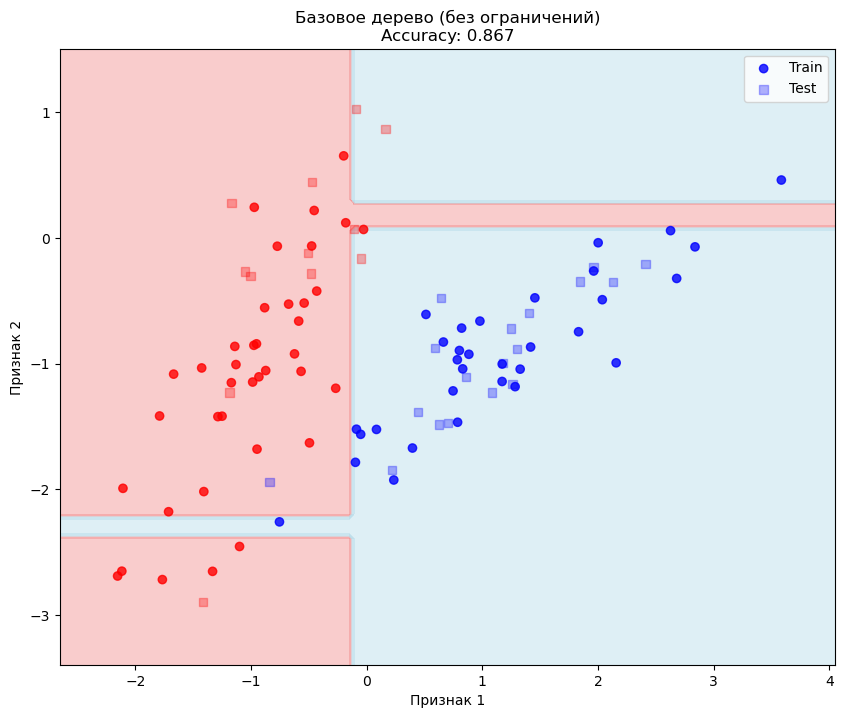

In [69]:
# 1. Базовое дерево без ограничений (для сравнения)
print("=== 1. Базовое дерево (без ограничений) ===")
base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)
base_train_acc = accuracy_score(y_train, base_tree.predict(X_train))
base_test_acc = accuracy_score(y_test, base_tree.predict(X_test))
print(f"Глубина дерева: {base_tree.get_depth()}")
print(f"Количество листьев: {base_tree.get_n_leaves()}")
print(f"Accuracy на обучающей выборке: {base_train_acc:.3f}")
print(f"Accuracy на тестовой выборке: {base_test_acc:.3f}")
visualize_tree(base_tree, X_train, y_train, X_test, y_test, "Базовое дерево (без ограничений)")


=== 2. Ограничение по глубине дерева (max_depth=3) ===
Глубина дерева: 3
Количество листьев: 6
Accuracy на обучающей выборке: 1.000
Accuracy на тестовой выборке: 0.867


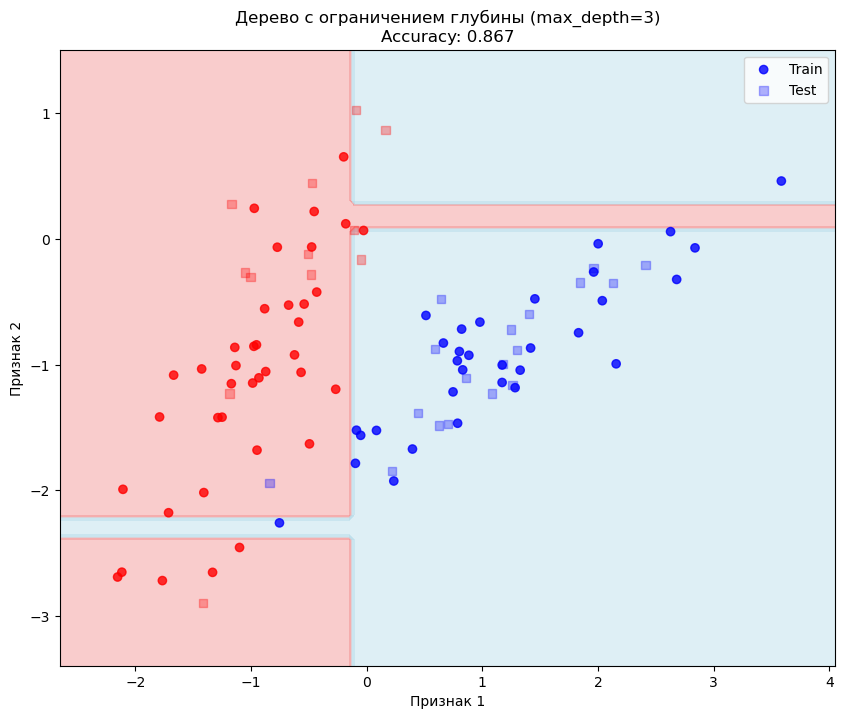

In [70]:
# 2. Ограничение по максимальной глубине дерева
print("\n=== 2. Ограничение по глубине дерева (max_depth=3) ===")
depth_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
depth_tree.fit(X_train, y_train)
depth_train_acc = accuracy_score(y_train, depth_tree.predict(X_train))
depth_test_acc = accuracy_score(y_test, depth_tree.predict(X_test))
print(f"Глубина дерева: {depth_tree.get_depth()}")
print(f"Количество листьев: {depth_tree.get_n_leaves()}")
print(f"Accuracy на обучающей выборке: {depth_train_acc:.3f}")
print(f"Accuracy на тестовой выборке: {depth_test_acc:.3f}")
visualize_tree(depth_tree, X_train, y_train, X_test, y_test, "Дерево с ограничением глубины (max_depth=3)")


=== 3. Ограничение по min_samples_leaf (min_samples_leaf=10) ===
Глубина дерева: 2
Количество листьев: 4
Accuracy на обучающей выборке: 0.971
Accuracy на тестовой выборке: 0.833


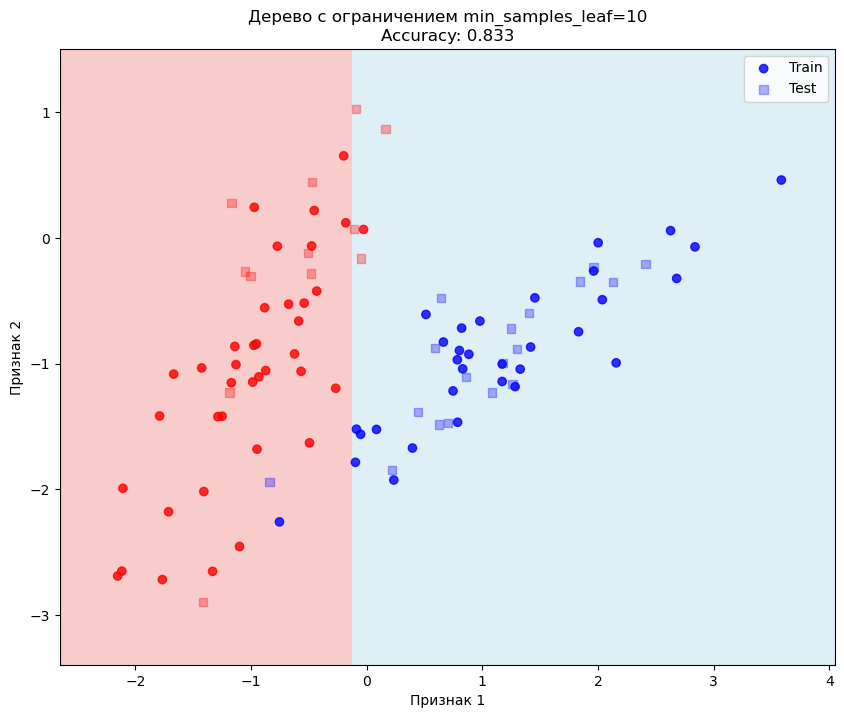

In [71]:
# 3. Ограничение по минимальному количеству образцов в листе
print("\n=== 3. Ограничение по min_samples_leaf (min_samples_leaf=10) ===")
leaf_tree = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
leaf_tree.fit(X_train, y_train)
leaf_train_acc = accuracy_score(y_train, leaf_tree.predict(X_train))
leaf_test_acc = accuracy_score(y_test, leaf_tree.predict(X_test))
print(f"Глубина дерева: {leaf_tree.get_depth()}")
print(f"Количество листьев: {leaf_tree.get_n_leaves()}")
print(f"Accuracy на обучающей выборке: {leaf_train_acc:.3f}")
print(f"Accuracy на тестовой выборке: {leaf_test_acc:.3f}")
visualize_tree(leaf_tree, X_train, y_train, X_test, y_test, "Дерево с ограничением min_samples_leaf=10")


=== 4. Ограничение по количеству листьев (max_leaf_nodes=5) ===
Глубина дерева: 3
Количество листьев: 5
Accuracy на обучающей выборке: 0.986
Accuracy на тестовой выборке: 0.933


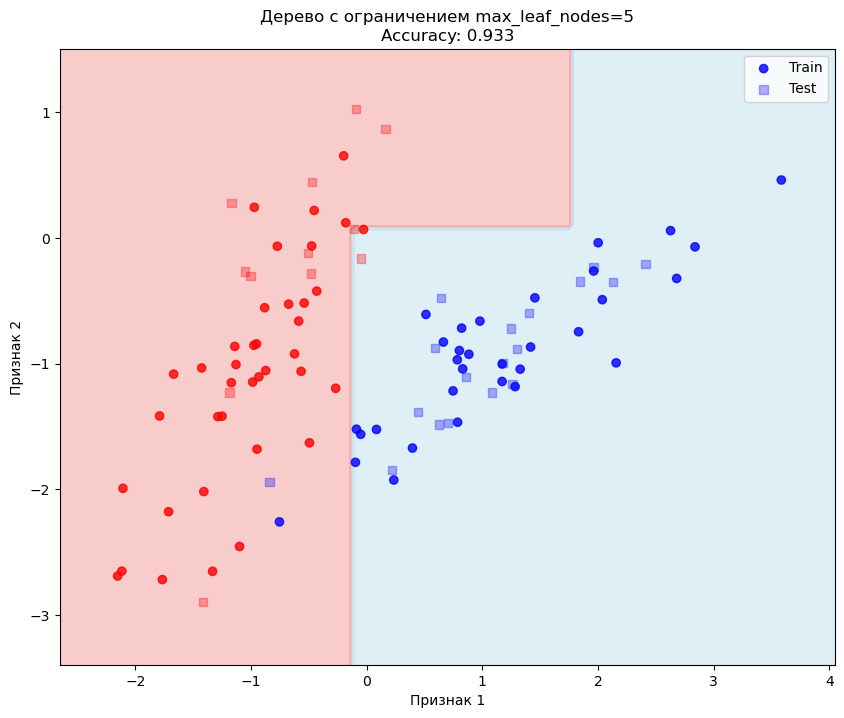

In [72]:
# 4. Ограничение по максимальному количеству листьев
print("\n=== 4. Ограничение по количеству листьев (max_leaf_nodes=5) ===")
leaf_nodes_tree = DecisionTreeClassifier(max_leaf_nodes=5, random_state=42)
leaf_nodes_tree.fit(X_train, y_train)
leaf_nodes_train_acc = accuracy_score(y_train, leaf_nodes_tree.predict(X_train))
leaf_nodes_test_acc = accuracy_score(y_test, leaf_nodes_tree.predict(X_test))
print(f"Глубина дерева: {leaf_nodes_tree.get_depth()}")
print(f"Количество листьев: {leaf_nodes_tree.get_n_leaves()}")
print(f"Accuracy на обучающей выборке: {leaf_nodes_train_acc:.3f}")
print(f"Accuracy на тестовой выборке: {leaf_nodes_test_acc:.3f}")
visualize_tree(leaf_nodes_tree, X_train, y_train, X_test, y_test, "Дерево с ограничением max_leaf_nodes=5")


=== 5. Ограничение по min_impurity_decrease (min_impurity_decrease=0.01) ===
Глубина дерева: 3
Количество листьев: 4
Accuracy на обучающей выборке: 0.986
Accuracy на тестовой выборке: 0.933


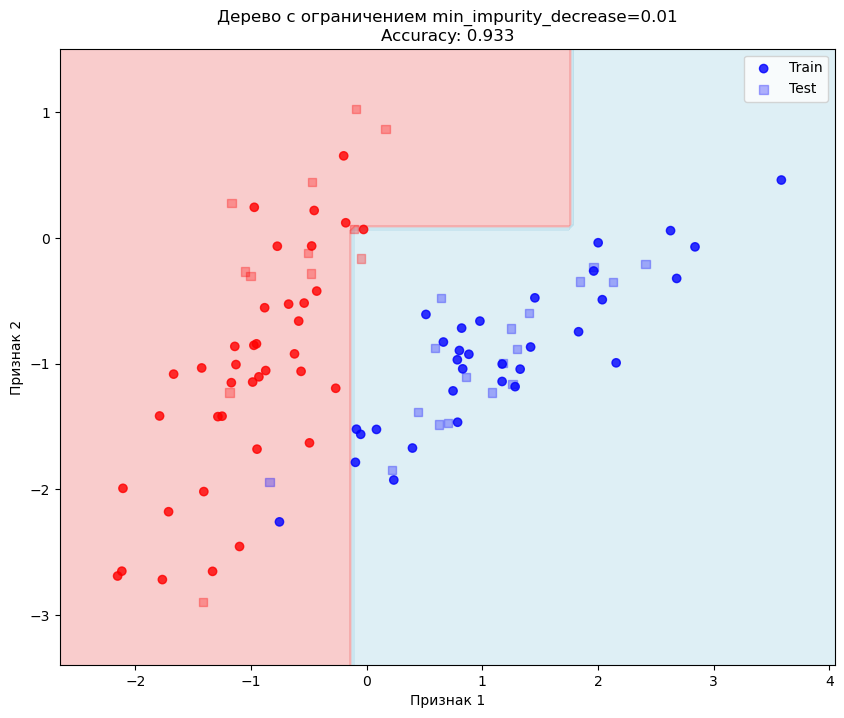

In [73]:
# 5. Ограничение по минимальному улучшению качества разделения
print("\n=== 5. Ограничение по min_impurity_decrease (min_impurity_decrease=0.01) ===")
impurity_tree = DecisionTreeClassifier(min_impurity_decrease=0.01, random_state=42)
impurity_tree.fit(X_train, y_train)
impurity_train_acc = accuracy_score(y_train, impurity_tree.predict(X_train))
impurity_test_acc = accuracy_score(y_test, impurity_tree.predict(X_test))
print(f"Глубина дерева: {impurity_tree.get_depth()}")
print(f"Количество листьев: {impurity_tree.get_n_leaves()}")
print(f"Accuracy на обучающей выборке: {impurity_train_acc:.3f}")
print(f"Accuracy на тестовой выборке: {impurity_test_acc:.3f}")
visualize_tree(impurity_tree, X_train, y_train, X_test, y_test, "Дерево с ограничением min_impurity_decrease=0.01")


=== 6. Комбинированный подход с несколькими ограничениями ===
Глубина дерева: 2
Количество листьев: 4
Accuracy на обучающей выборке: 0.971
Accuracy на тестовой выборке: 0.833


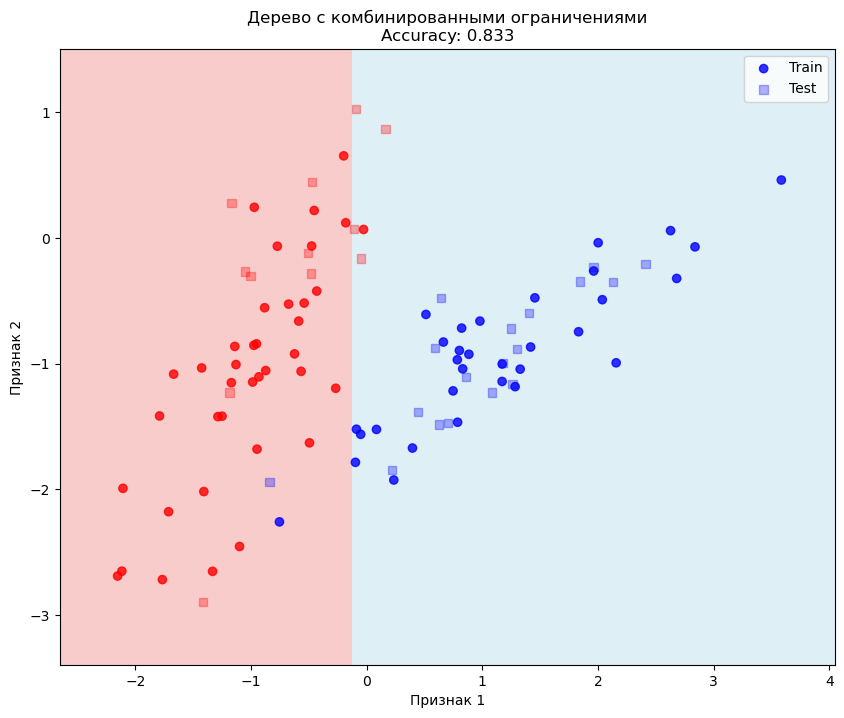

In [74]:
# 6. Комбинированный подход с несколькими ограничениями
print("\n=== 6. Комбинированный подход с несколькими ограничениями ===")
combined_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    max_leaf_nodes=8,
    random_state=42
)
combined_tree.fit(X_train, y_train)
combined_train_acc = accuracy_score(y_train, combined_tree.predict(X_train))
combined_test_acc = accuracy_score(y_test, combined_tree.predict(X_test))
print(f"Глубина дерева: {combined_tree.get_depth()}")
print(f"Количество листьев: {combined_tree.get_n_leaves()}")
print(f"Accuracy на обучающей выборке: {combined_train_acc:.3f}")
print(f"Accuracy на тестовой выборке: {combined_test_acc:.3f}")
visualize_tree(combined_tree, X_train, y_train, X_test, y_test, "Дерево с комбинированными ограничениями")

In [75]:
# Сравнительная таблица результатов
print("\n" + "="*60)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)
results = [
    ["Метод", "Глубина", "Листья", "Train Acc", "Test Acc"],
    ["Без ограничений", base_tree.get_depth(), base_tree.get_n_leaves(), f"{base_train_acc:.3f}", f"{base_test_acc:.3f}"],
    ["max_depth=3", depth_tree.get_depth(), depth_tree.get_n_leaves(), f"{depth_train_acc:.3f}", f"{depth_test_acc:.3f}"],
    ["min_samples_leaf=10", leaf_tree.get_depth(), leaf_tree.get_n_leaves(), f"{leaf_train_acc:.3f}", f"{leaf_test_acc:.3f}"],
    ["max_leaf_nodes=5", leaf_nodes_tree.get_depth(), leaf_nodes_tree.get_n_leaves(), f"{leaf_nodes_train_acc:.3f}", f"{leaf_nodes_test_acc:.3f}"],
    ["min_impurity_decrease=0.01", impurity_tree.get_depth(), impurity_tree.get_n_leaves(), f"{impurity_train_acc:.3f}", f"{impurity_test_acc:.3f}"],
    ["Комбинированный", combined_tree.get_depth(), combined_tree.get_n_leaves(), f"{combined_train_acc:.3f}", f"{combined_test_acc:.3f}"]
]

for row in results:
    print(f"{row[0]:30} {str(row[1]):10} {str(row[2]):10} {row[3]:12} {row[4]:12}")


СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Метод                          Глубина    Листья     Train Acc    Test Acc    
Без ограничений                3          6          1.000        0.867       
max_depth=3                    3          6          1.000        0.867       
min_samples_leaf=10            2          4          0.971        0.833       
max_leaf_nodes=5               3          5          0.986        0.933       
min_impurity_decrease=0.01     3          4          0.986        0.933       
Комбинированный                2          4          0.971        0.833       


#### СРАВНЕНИЕ КРИТЕРИЕВ РАЗБИЕНИЯ: ДЖИНИ vs ЭНТРОПИЯ

In [76]:
# Дерево с критерием Джини (по умолчанию)
gini_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
gini_tree.fit(X_train, y_train)
gini_train_acc = accuracy_score(y_train, gini_tree.predict(X_train))
gini_test_acc = accuracy_score(y_test, gini_tree.predict(X_test))

In [77]:
# Дерево с критерием Энтропия
entropy_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
entropy_tree.fit(X_train, y_train)
entropy_train_acc = accuracy_score(y_train, entropy_tree.predict(X_train))
entropy_test_acc = accuracy_score(y_test, entropy_tree.predict(X_test))

In [78]:
# Базовые деревья с разными критериями (без ограничений)
print("\n=== 1. Базовые деревья без ограничений ===")

print(f"\nКритерий 'gini':")
print(f"  Глубина дерева: {gini_tree.get_depth()}")
print(f"  Количество листьев: {gini_tree.get_n_leaves()}")
print(f"  Accuracy на обучающей выборке: {gini_train_acc:.4f}")
print(f"  Accuracy на тестовой выборке: {gini_test_acc:.4f}")
print(f"  Переобучение (разница train-test): {gini_train_acc - gini_test_acc:.4f}")

print(f"\nКритерий 'entropy':")
print(f"  Глубина дерева: {entropy_tree.get_depth()}")
print(f"  Количество листьев: {entropy_tree.get_n_leaves()}")
print(f"  Accuracy на обучающей выборке: {entropy_train_acc:.4f}")
print(f"  Accuracy на тестовой выборке: {entropy_test_acc:.4f}")
print(f"  Переобучение (разница train-test): {entropy_train_acc - entropy_test_acc:.4f}")


=== 1. Базовые деревья без ограничений ===

Критерий 'gini':
  Глубина дерева: 3
  Количество листьев: 6
  Accuracy на обучающей выборке: 1.0000
  Accuracy на тестовой выборке: 0.8667
  Переобучение (разница train-test): 0.1333

Критерий 'entropy':
  Глубина дерева: 3
  Количество листьев: 6
  Accuracy на обучающей выборке: 1.0000
  Accuracy на тестовой выборке: 0.8667
  Переобучение (разница train-test): 0.1333


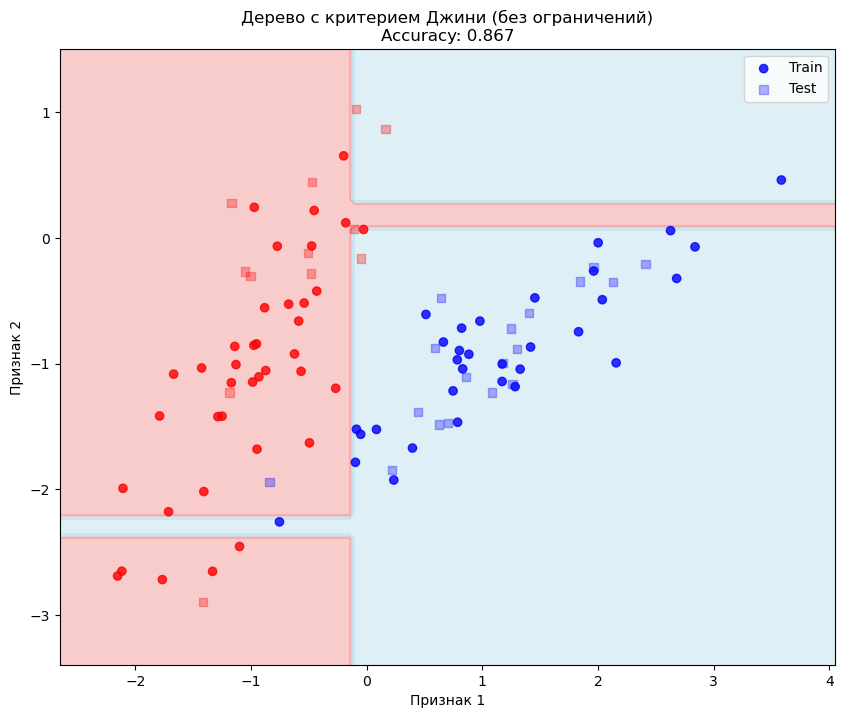

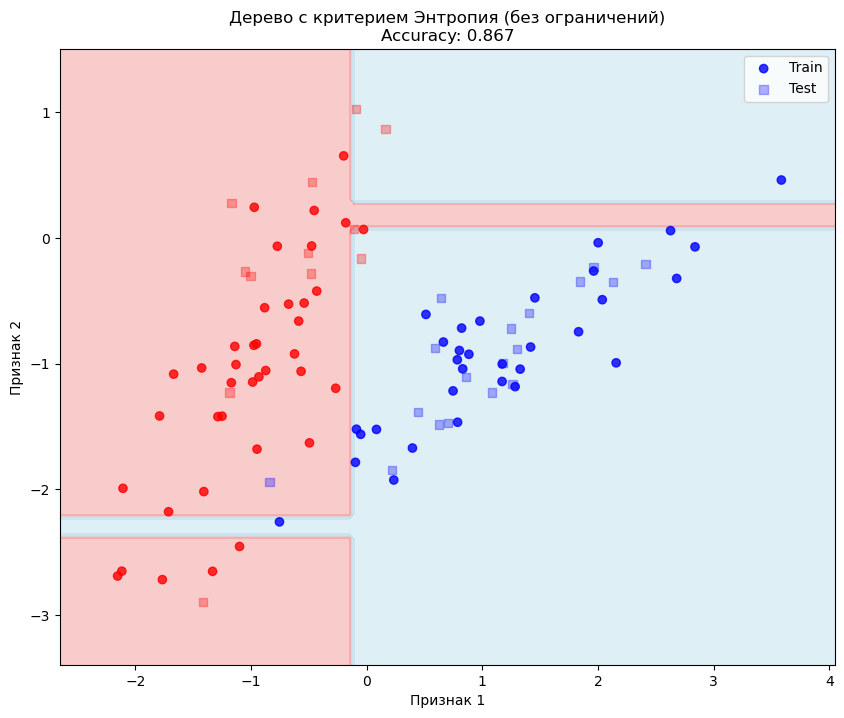

In [79]:
# Визуализация
visualize_tree(gini_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Джини (без ограничений)")
visualize_tree(entropy_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Энтропия (без ограничений)")


In [80]:
# 2. Сравнение с ограничением по глубине (max_depth=3)
print("\n=== 2. С ограничением глубины (max_depth=3) ===")

gini_depth_tree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
entropy_depth_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

gini_depth_tree.fit(X_train, y_train)
entropy_depth_tree.fit(X_train, y_train)

gini_depth_train_acc = accuracy_score(y_train, gini_depth_tree.predict(X_train))
gini_depth_test_acc = accuracy_score(y_test, gini_depth_tree.predict(X_test))
entropy_depth_train_acc = accuracy_score(y_train, entropy_depth_tree.predict(X_train))
entropy_depth_test_acc = accuracy_score(y_test, entropy_depth_tree.predict(X_test))

print(f"\nКритерий 'gini' (max_depth=3):")
print(f"  Accuracy train/test: {gini_depth_train_acc:.4f}/{gini_depth_test_acc:.4f}")

print(f"\nКритерий 'entropy' (max_depth=3):")
print(f"  Accuracy train/test: {entropy_depth_train_acc:.4f}/{entropy_depth_test_acc:.4f}")


=== 2. С ограничением глубины (max_depth=3) ===

Критерий 'gini' (max_depth=3):
  Accuracy train/test: 1.0000/0.8667

Критерий 'entropy' (max_depth=3):
  Accuracy train/test: 1.0000/0.8667


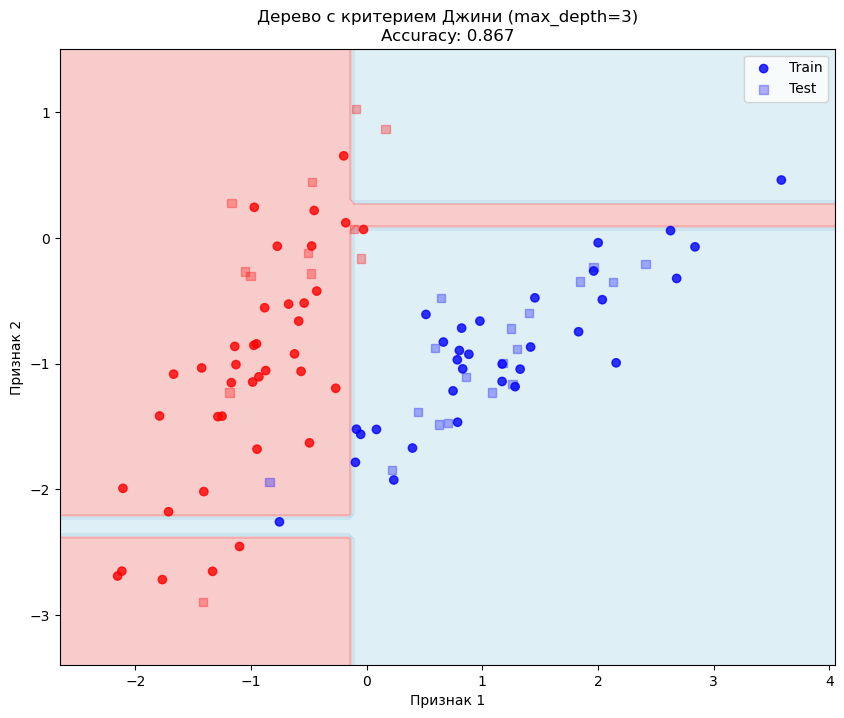

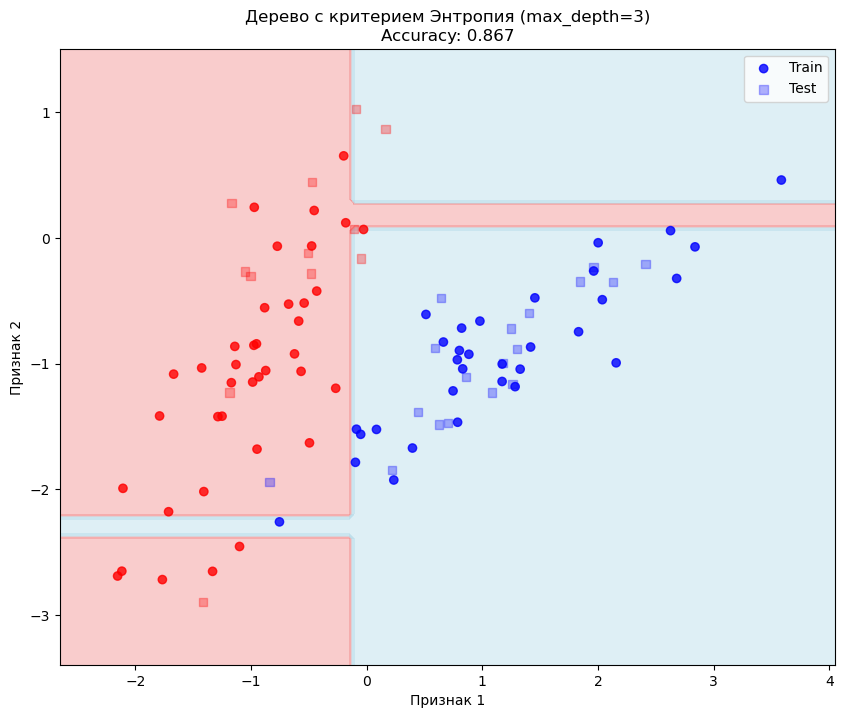

In [81]:
visualize_tree(gini_depth_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Джини (max_depth=3)")
visualize_tree(entropy_depth_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Энтропия (max_depth=3)")

In [82]:
# 3. Сравнение с ограничением по минимальному количеству образцов в листе
print("\n=== 3. С ограничением min_samples_leaf=10 ===")

gini_leaf_tree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=10, random_state=42)
entropy_leaf_tree = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10, random_state=42)

gini_leaf_tree.fit(X_train, y_train)
entropy_leaf_tree.fit(X_train, y_train)

gini_leaf_train_acc = accuracy_score(y_train, gini_leaf_tree.predict(X_train))
gini_leaf_test_acc = accuracy_score(y_test, gini_leaf_tree.predict(X_test))
entropy_leaf_train_acc = accuracy_score(y_train, entropy_leaf_tree.predict(X_train))
entropy_leaf_test_acc = accuracy_score(y_test, entropy_leaf_tree.predict(X_test))

print(f"\nКритерий 'gini' (min_samples_leaf=10):")
print(f"  Accuracy train/test: {gini_leaf_train_acc:}/{gini_leaf_test_acc:.4f}")

print(f"\nКритерий 'entropy' (min_samples_leaf=10):")
print(f"  Accuracy train/test: {entropy_leaf_train_acc:}/{entropy_leaf_test_acc:.4f}")


=== 3. С ограничением min_samples_leaf=10 ===

Критерий 'gini' (min_samples_leaf=10):
  Accuracy train/test: 0.9714285714285714/0.8333

Критерий 'entropy' (min_samples_leaf=10):
  Accuracy train/test: 0.9714285714285714/0.8333


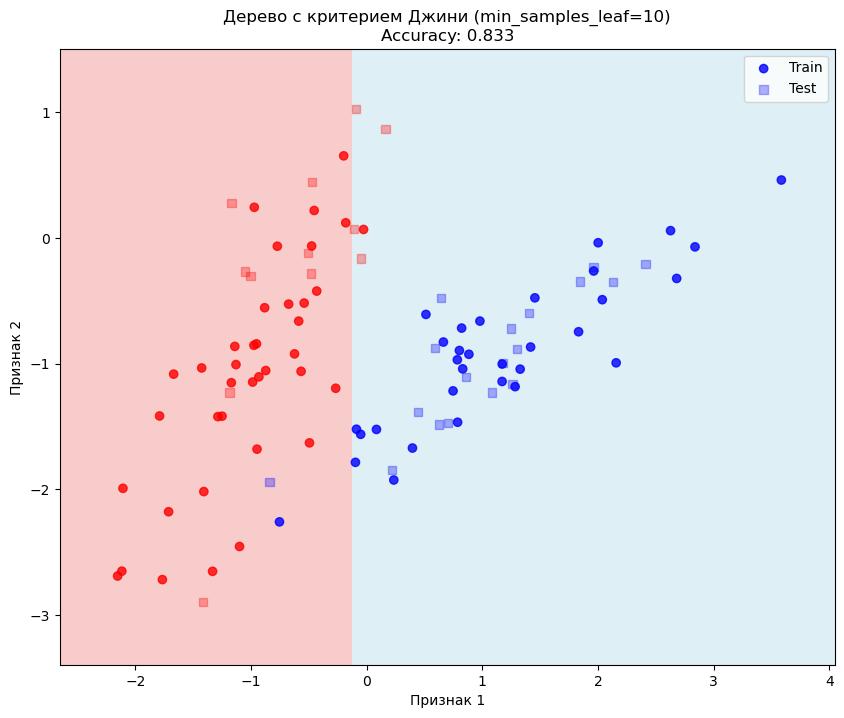

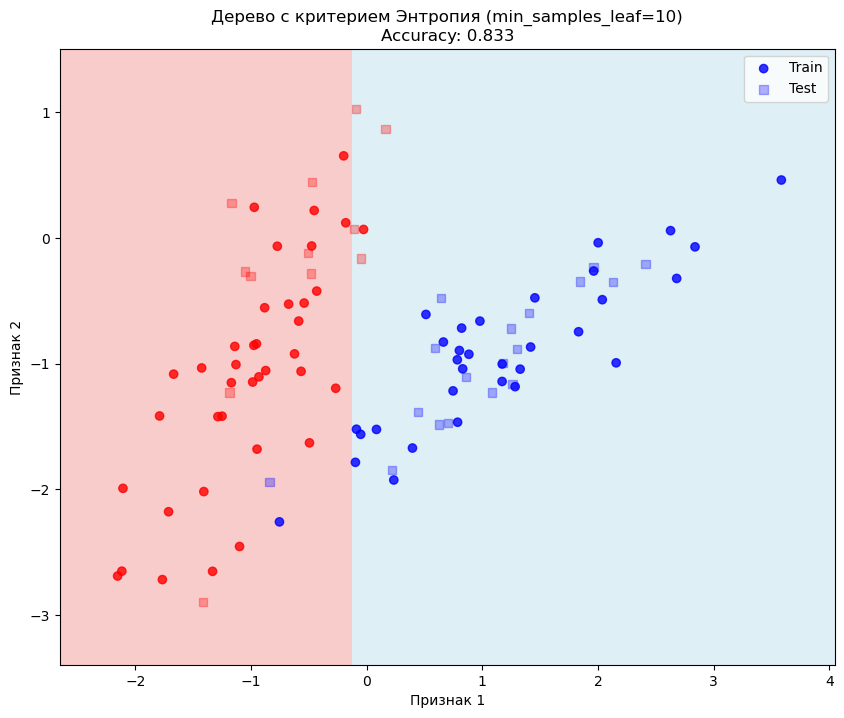

In [83]:
visualize_tree(gini_leaf_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Джини (min_samples_leaf=10)")
visualize_tree(entropy_leaf_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Энтропия (min_samples_leaf=10)")


In [84]:
# 4. Сравнение с комбинированными ограничениями

combined_gini_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=5,
    max_leaf_nodes=8,
    random_state=42
)

combined_entropy_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_leaf=5,
    max_leaf_nodes=8,
    random_state=42
)

In [85]:
combined_gini_tree.fit(X_train, y_train)
combined_entropy_tree.fit(X_train, y_train)

combined_gini_train_acc = accuracy_score(y_train, combined_gini_tree.predict(X_train))
combined_gini_test_acc = accuracy_score(y_test, combined_gini_tree.predict(X_test))
combined_entropy_train_acc = accuracy_score(y_train, combined_entropy_tree.predict(X_train))
combined_entropy_test_acc = accuracy_score(y_test, combined_entropy_tree.predict(X_test))

In [86]:
print("\n=== 4. С комбинированными ограничениями ===")

print(f"\nКритерий 'gini' (комбинированный):")
print(f"  Accuracy train/test: {combined_gini_train_acc:.4f}/{combined_gini_test_acc:.4f}")
print(f"  Глубина: {combined_gini_tree.get_depth()}, Листьев: {combined_gini_tree.get_n_leaves()}")

print(f"\nКритерий 'entropy' (комбинированный):")
print(f"  Accuracy train/test: {combined_entropy_train_acc:.4f}/{combined_entropy_test_acc:.4f}")
print(f"  Глубина: {combined_entropy_tree.get_depth()}, Листьев: {combined_entropy_tree.get_n_leaves()}")


=== 4. С комбинированными ограничениями ===

Критерий 'gini' (комбинированный):
  Accuracy train/test: 0.9714/0.8333
  Глубина: 2, Листьев: 4

Критерий 'entropy' (комбинированный):
  Accuracy train/test: 0.9714/0.8333
  Глубина: 2, Листьев: 4


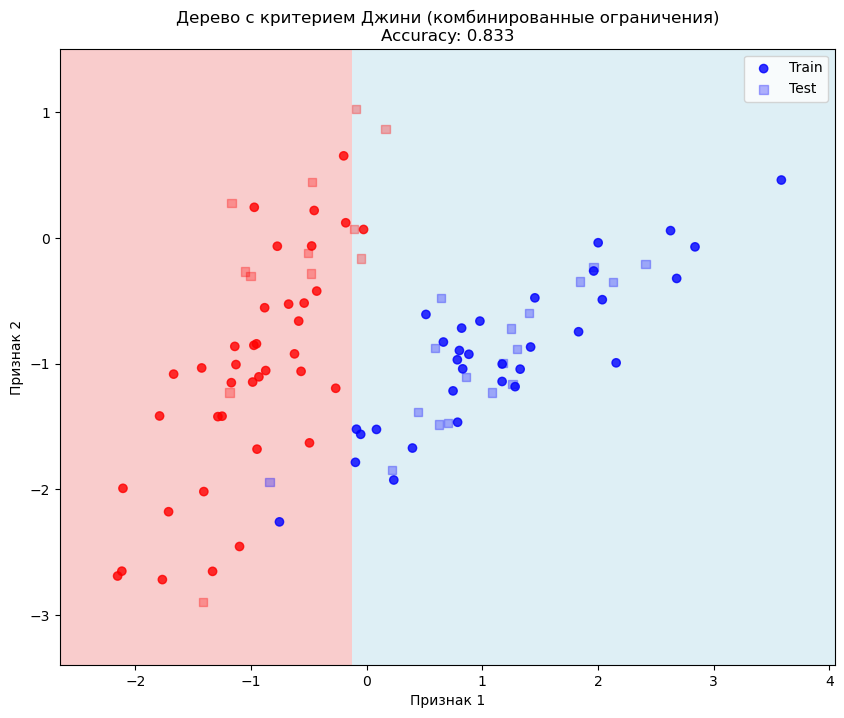

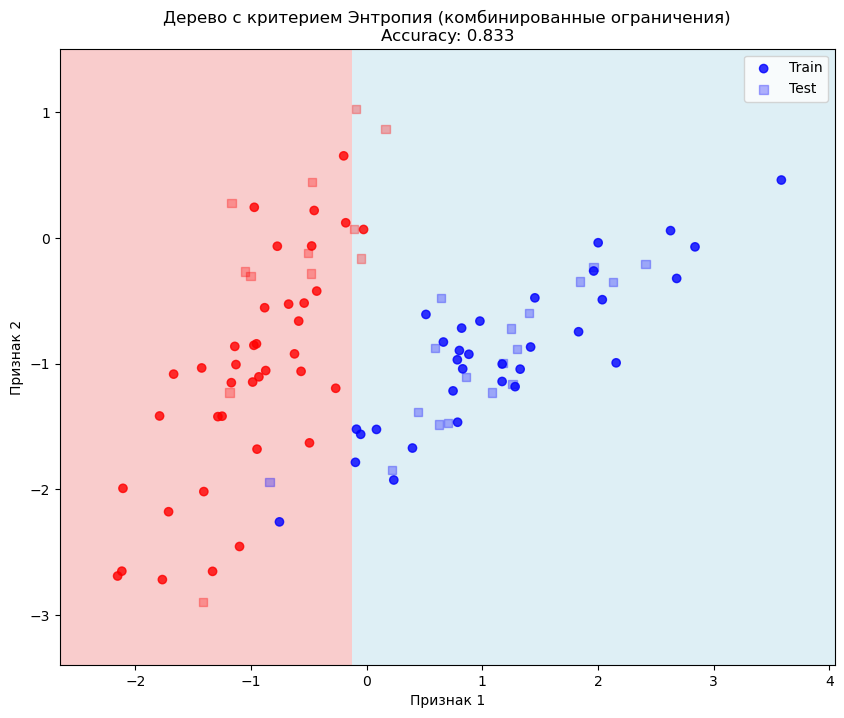

In [87]:
visualize_tree(combined_gini_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Джини (комбинированные ограничения)")
visualize_tree(combined_entropy_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Энтропия (комбинированные ограничения)")

In [88]:
import time

In [89]:
# Измерим время обучения для каждого критерия
def measure_training_time(criterion, **params):
    tree = DecisionTreeClassifier(criterion=criterion, **params, random_state=42)
    start_time = time.time()
    tree.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Измерим время предсказания
    start_time = time.time()
    predictions = tree.predict(X_test)
    prediction_time = time.time() - start_time
    
    return tree, training_time, prediction_time

In [90]:
print("\nСравнение времени выполнения (без ограничений):")
gini_tree, gini_train_time, gini_pred_time = measure_training_time('gini')
entropy_tree, entropy_train_time, entropy_pred_time = measure_training_time('entropy')

print(f"Критерий 'gini':")
print(f"  Время обучения: {gini_train_time:.6f} сек")
print(f"  Время предсказания: {gini_pred_time:.6f} сек")

print(f"\nКритерий 'entropy':")
print(f"  Время обучения: {entropy_train_time:.6f} сек")
print(f"  Время предсказания: {entropy_pred_time:.6f} сек")

print(f"\nОтносительная разница во времени обучения: {((entropy_train_time - gini_train_time)/gini_train_time*100):.2f}%")


Сравнение времени выполнения (без ограничений):
Критерий 'gini':
  Время обучения: 0.001717 сек
  Время предсказания: 0.000323 сек

Критерий 'entropy':
  Время обучения: 0.001612 сек
  Время предсказания: 0.000479 сек

Относительная разница во времени обучения: -6.08%


In [91]:
# 6. Итоговая сравнительная таблица
print("\n" + "="*80)
print("ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("="*80)

results = [
    ["Конфигурация", "Критерий", "Глубина", "Листья", "Train Acc", "Test Acc", "Разница"],
    ["-"*70],
    ["Без ограничений", "gini", gini_tree.get_depth(), gini_tree.get_n_leaves(), 
     f"{gini_train_acc:.4f}", f"{gini_test_acc:.4f}", f"{gini_train_acc - gini_test_acc:.4f}"],
    ["Без ограничений", "entropy", entropy_tree.get_depth(), entropy_tree.get_n_leaves(), 
     f"{entropy_train_acc:.4f}", f"{entropy_test_acc:.4f}", f"{entropy_train_acc - entropy_test_acc:.4f}"],
    ["-"*70],
    ["max_depth=3", "gini", gini_depth_tree.get_depth(), gini_depth_tree.get_n_leaves(), 
     f"{gini_depth_train_acc:.4f}", f"{gini_depth_test_acc:.4f}", f"{gini_depth_train_acc - gini_depth_test_acc:.4f}"],
    ["max_depth=3", "entropy", entropy_depth_tree.get_depth(), entropy_depth_tree.get_n_leaves(), 
     f"{entropy_depth_train_acc:.4f}", f"{entropy_depth_test_acc:.4f}", f"{entropy_depth_train_acc - entropy_depth_test_acc:.4f}"],
    ["-"*70],
    ["min_samples_leaf=10", "gini", gini_leaf_tree.get_depth(), gini_leaf_tree.get_n_leaves(), 
     f"{gini_leaf_train_acc:.4f}", f"{gini_leaf_test_acc:.4f}", f"{gini_leaf_train_acc - gini_leaf_test_acc:.4f}"],
    ["min_samples_leaf=10", "entropy", entropy_leaf_tree.get_depth(), entropy_leaf_tree.get_n_leaves(), 
     f"{entropy_leaf_train_acc:.4f}", f"{entropy_leaf_test_acc:.4f}", f"{entropy_leaf_train_acc - entropy_leaf_test_acc:.4f}"],
    ["-"*70],
    ["Комбинированный", "gini", combined_gini_tree.get_depth(), combined_gini_tree.get_n_leaves(), 
     f"{combined_gini_train_acc:.4f}", f"{combined_gini_test_acc:.4f}", f"{combined_gini_train_acc - combined_gini_test_acc:.4f}"],
    ["Комбинированный", "entropy", combined_entropy_tree.get_depth(), combined_entropy_tree.get_n_leaves(), 
     f"{combined_entropy_train_acc:.4f}", f"{combined_entropy_test_acc:.4f}", f"{combined_entropy_train_acc - combined_entropy_test_acc:.4f}"],
]

for row in results:
    if len(row) == 7:
        print(f"{row[0]:25} {row[1]:10} {str(row[2]):8} {str(row[3]):8} {row[4]:10} {row[5]:10} {row[6]:10}")
    else:
        print(row[0])


ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА
Конфигурация              Критерий   Глубина  Листья   Train Acc  Test Acc   Разница   
----------------------------------------------------------------------
Без ограничений           gini       3        6        1.0000     0.8667     0.1333    
Без ограничений           entropy    3        6        1.0000     0.8667     0.1333    
----------------------------------------------------------------------
max_depth=3               gini       3        6        1.0000     0.8667     0.1333    
max_depth=3               entropy    3        6        1.0000     0.8667     0.1333    
----------------------------------------------------------------------
min_samples_leaf=10       gini       2        4        0.9714     0.8333     0.1381    
min_samples_leaf=10       entropy    2        4        0.9714     0.8333     0.1381    
----------------------------------------------------------------------
Комбинированный           gini       2        4        0.9714     0.

#### Вывод:
Критерии Джини и Энтропия часто дают одинаковые результаты потому что:

1. НА ПРОСТЫХ ДАННЫХ: Существует ограниченное количество "очевидных" 
   точек разбиения, и оба критерия выбирают одни и те же.

2. МАТЕМАТИЧЕСКАЯ ПОХОЖЕСТЬ: Оба критерия измеряют "нечистоту" узлов
   и имеют схожие свойства оптимизации.

3. ДИСКРЕТНЫЕ РАЗБИЕНИЯ: В деревьях решения разбиения происходят по 
   конкретным значениям признаков, что ограничивает варианты.

Различия проявляются когда:
- Данные сложные (много перекрытий, шум)
- Мультиклассовая классификация (>2 классов)
- Несбалансированные данные
- Признаки имеют разные масштабы/распределения
- Используются очень глубокие деревья без ограничений

НО даже в этих случаях различия обычно незначительны (менее 1-2% accuracy).
Поэтому на практике часто используют Джини как более быстрый вариант.

#### Сгенерируем набор данных чтобы увидеть реальные различия, нужно создать данные, где критерии действительно будут по-разному оценивать качество разбиения.

In [110]:
classification_data, classification_labels = datasets.make_classification(
    n_features=2,               # Количество признаков (фичей) в данных
    n_informative=2,            # Количество информативных признаков (которые действительно влияют на класс)
    n_classes=2,                # Количество классов для классификации
    n_redundant=0,              # Количество избыточных признаков (линейные комбинации информативных)
    n_clusters_per_class=2,     # Количество кластеров (групп) на каждый класс
    
    # Параметры, влияющие на сложность данных:
    n_samples=1500,             # Общее количество образцов (строк данных)
    flip_y=0.4,                 # Доля шума в данных (40% меток будут перевернуты случайным образом)
    
    # Параметры разделимости классов:
    class_sep=0.3,              # Степень разделимости классов (меньше = сложнее разделить)
    
    # Геометрические параметры распределения данных:
    hypercube=False,            # Если True, кластеры размещаются в вершинах гиперкуба
    shift=0.5,                  # Сдвиг центров кластеров (добавляет смещение)
    scale=2.0,                  # Масштаб разброса точек вокруг центров кластеров
    
    # Воспроизводимость:
    random_state=42             # Seed для генератора случайных чисел (для воспроизводимости)
)

In [111]:
# разбиваем выборку
X_train, X_test, y_train, y_test = train_test_split(
    classification_data, classification_labels, test_size=0.3, random_state=42
)

In [112]:
# Дерево с критерием Джини (по умолчанию)
gini_tree = DecisionTreeClassifier(criterion='gini',min_samples_leaf=10, random_state=42)
gini_tree.fit(X_train, y_train)
gini_train_acc = accuracy_score(y_train, gini_tree.predict(X_train))
gini_test_acc = accuracy_score(y_test, gini_tree.predict(X_test))

In [113]:
# Дерево с критерием Энтропия
entropy_tree = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10, random_state=42)
entropy_tree.fit(X_train, y_train)
entropy_train_acc = accuracy_score(y_train, entropy_tree.predict(X_train))
entropy_test_acc = accuracy_score(y_test, entropy_tree.predict(X_test))


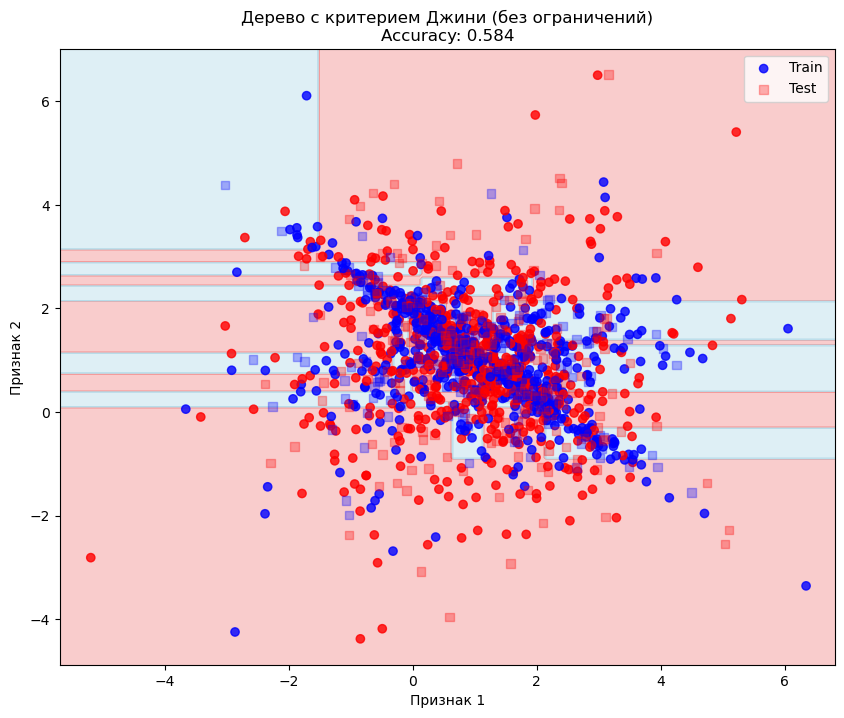

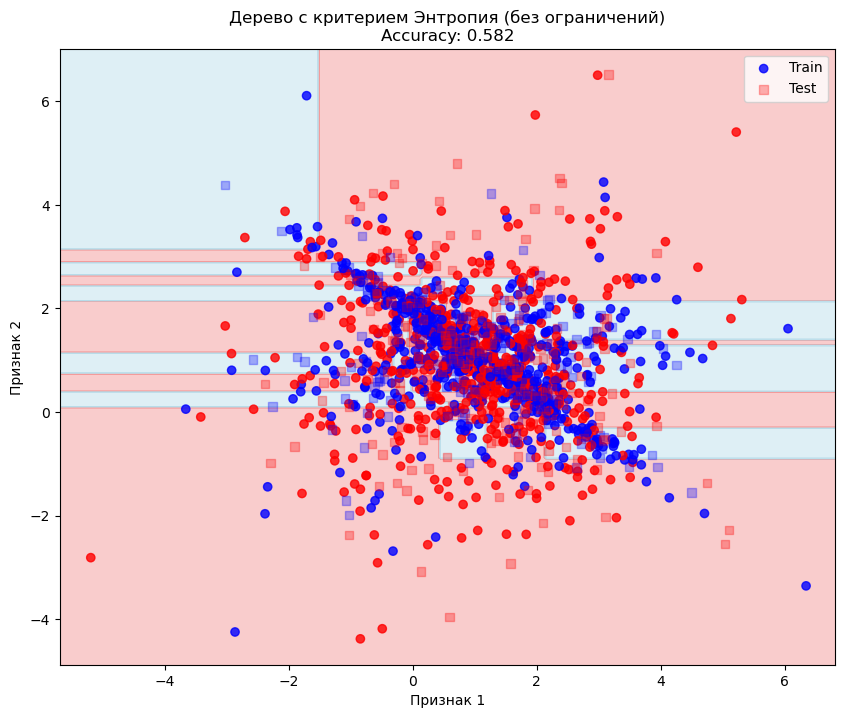

In [114]:
# Визуализация
visualize_tree(gini_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Джини (без ограничений)")
visualize_tree(entropy_tree, X_train, y_train, X_test, y_test, "Дерево с критерием Энтропия (без ограничений)")

In [115]:
# Базовые деревья с разными критериями (без ограничений)
print("\n=== 1. Базовые деревья без ограничений ===")

print(f"\nКритерий 'gini':")
print(f"  Глубина дерева: {gini_tree.get_depth()}")
print(f"  Количество листьев: {gini_tree.get_n_leaves()}")
print(f"  Accuracy на обучающей выборке: {gini_train_acc:.4f}")
print(f"  Accuracy на тестовой выборке: {gini_test_acc:.4f}")
print(f"  Переобучение (разница train-test): {gini_train_acc - gini_test_acc:.4f}")

print(f"\nКритерий 'entropy':")
print(f"  Глубина дерева: {entropy_tree.get_depth()}")
print(f"  Количество листьев: {entropy_tree.get_n_leaves()}")
print(f"  Accuracy на обучающей выборке: {entropy_train_acc:.4f}")
print(f"  Accuracy на тестовой выборке: {entropy_test_acc:.4f}")
print(f"  Переобучение (разница train-test): {entropy_train_acc - entropy_test_acc:.4f}")


=== 1. Базовые деревья без ограничений ===

Критерий 'gini':
  Глубина дерева: 15
  Количество листьев: 84
  Accuracy на обучающей выборке: 0.7257
  Accuracy на тестовой выборке: 0.5844
  Переобучение (разница train-test): 0.1413

Критерий 'entropy':
  Глубина дерева: 15
  Количество листьев: 84
  Accuracy на обучающей выборке: 0.7305
  Accuracy на тестовой выборке: 0.5822
  Переобучение (разница train-test): 0.1483
